In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.eda_utils import *

In [4]:
df = pd.read_csv(
    "../data/MachineLearningRating_v3.txt",
    sep="|"
)

C:\Users\betya\AppData\Local\Temp\ipykernel_19940\3541705735.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [5]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [6]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

In [7]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Converted                   641901
WrittenOff                  641901
Rebuilt                     641901
LossRatio                   381484
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
NumberOfDoors                  552
VehicleIntroDate               552
VehicleType                    552
cubiccapacity                  552
Model                          552
Cylinders                      552
kilowatts                      552
bodytype                       552
mmcode                         552
make                           552
CapitalOutstanding               2
dtype: int64

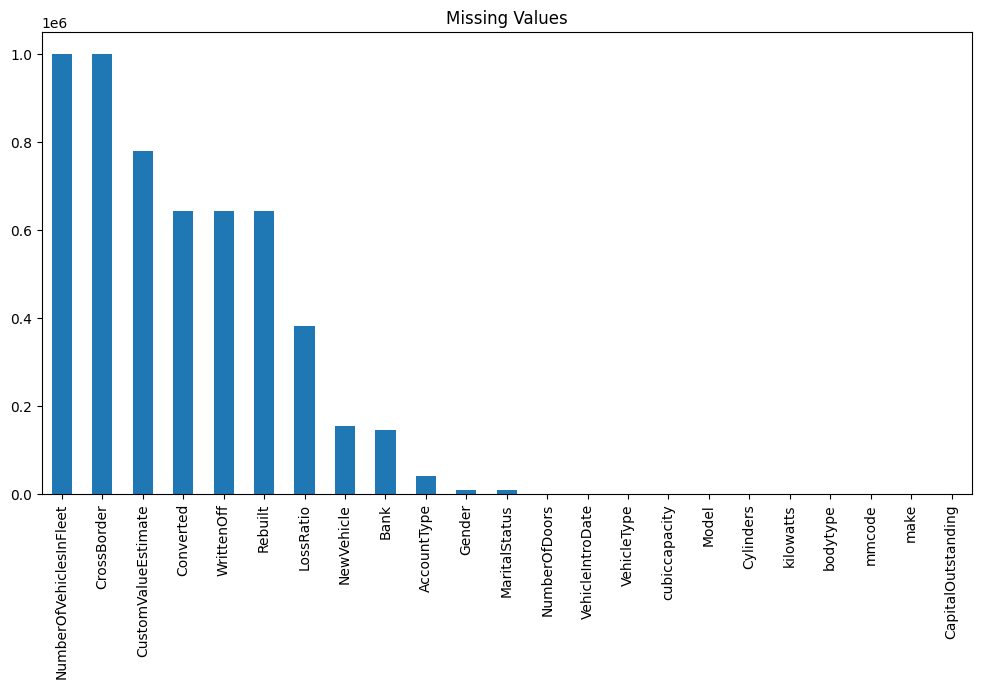

In [8]:
plt.figure(figsize=(12,6))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values")
plt.show()

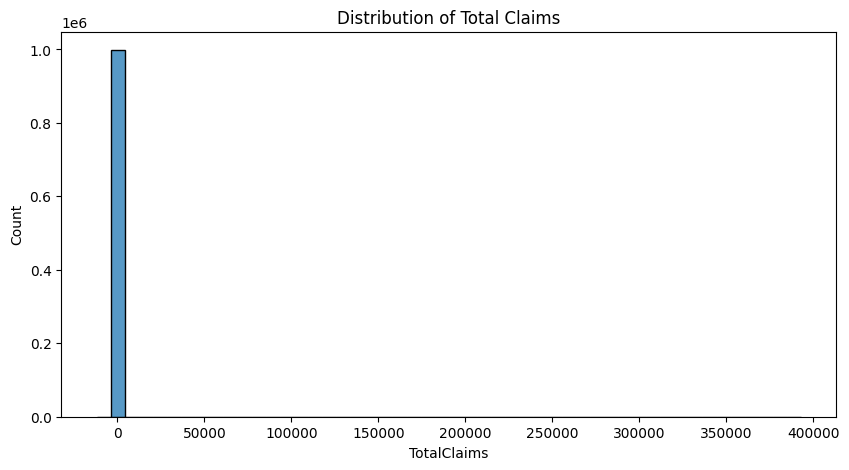

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df["TotalClaims"], bins=50)
plt.title("Distribution of Total Claims")
plt.show()

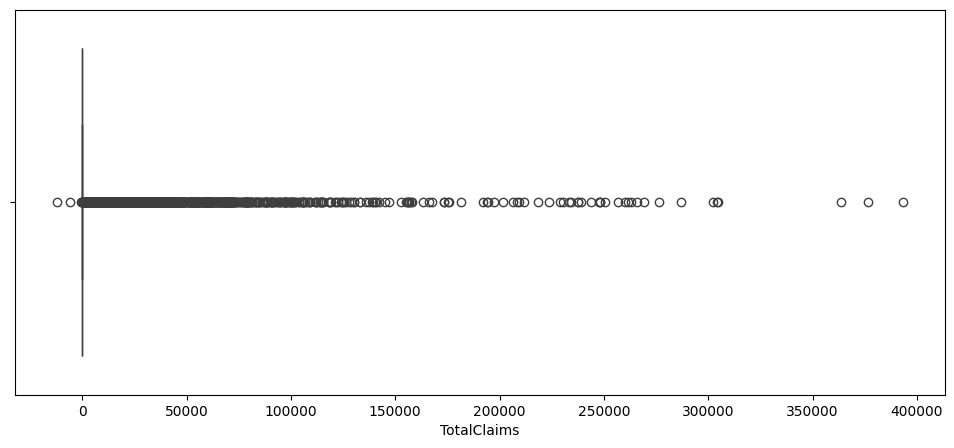

In [10]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df["TotalClaims"])
plt.show()

c:\Users\betya\Desktop\insranceriskanalysis\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\betya\Desktop\insranceriskanalysis\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


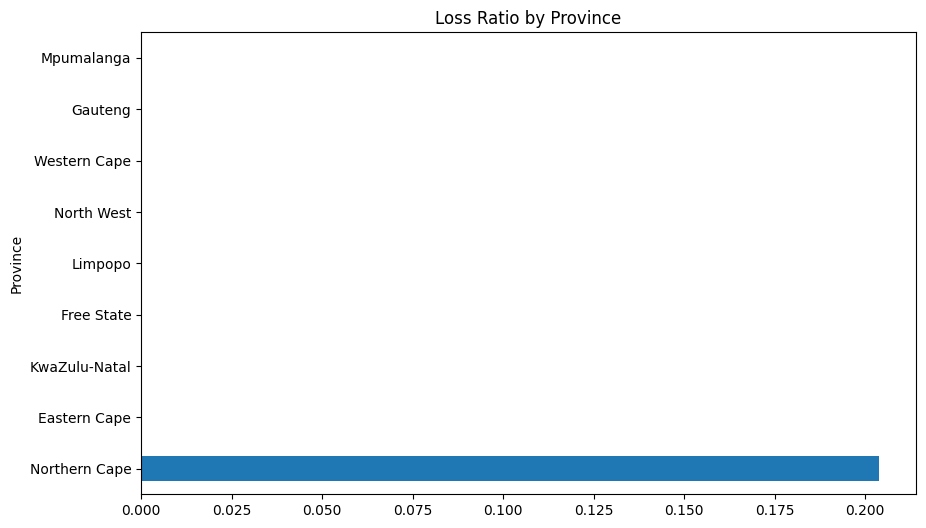

In [11]:
province_risk = df.groupby("Province")["LossRatio"].mean().sort_values()

province_risk.plot(kind="barh", figsize=(10,6))
plt.title("Loss Ratio by Province")
plt.show()

In [12]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

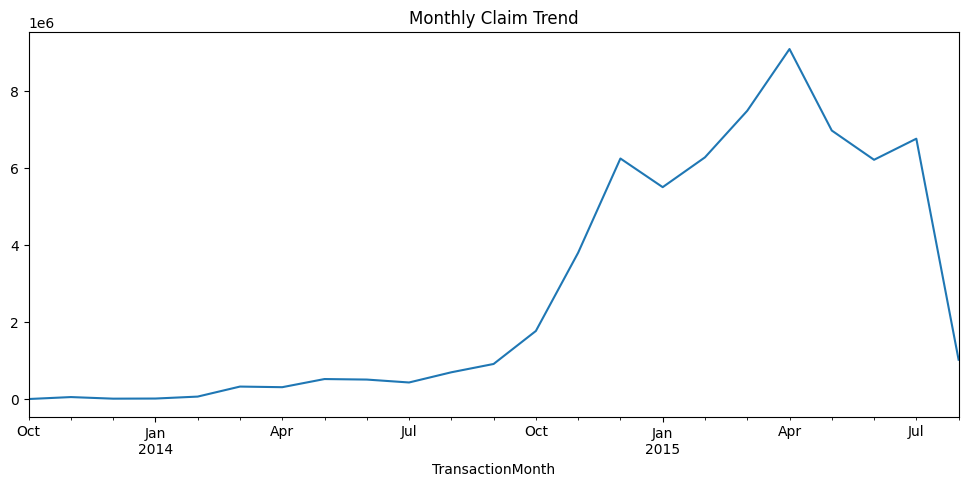

In [13]:
monthly_claims = df.groupby(
    df["TransactionMonth"].dt.to_period("M")
)["TotalClaims"].sum()

monthly_claims.plot(figsize=(12,5))
plt.title("Monthly Claim Trend")
plt.show()

In [14]:
vehicle_claims = df.groupby("Make")["TotalClaims"].mean()

vehicle_claims.sort_values(ascending=False).head(10)

KeyError: 'Make'

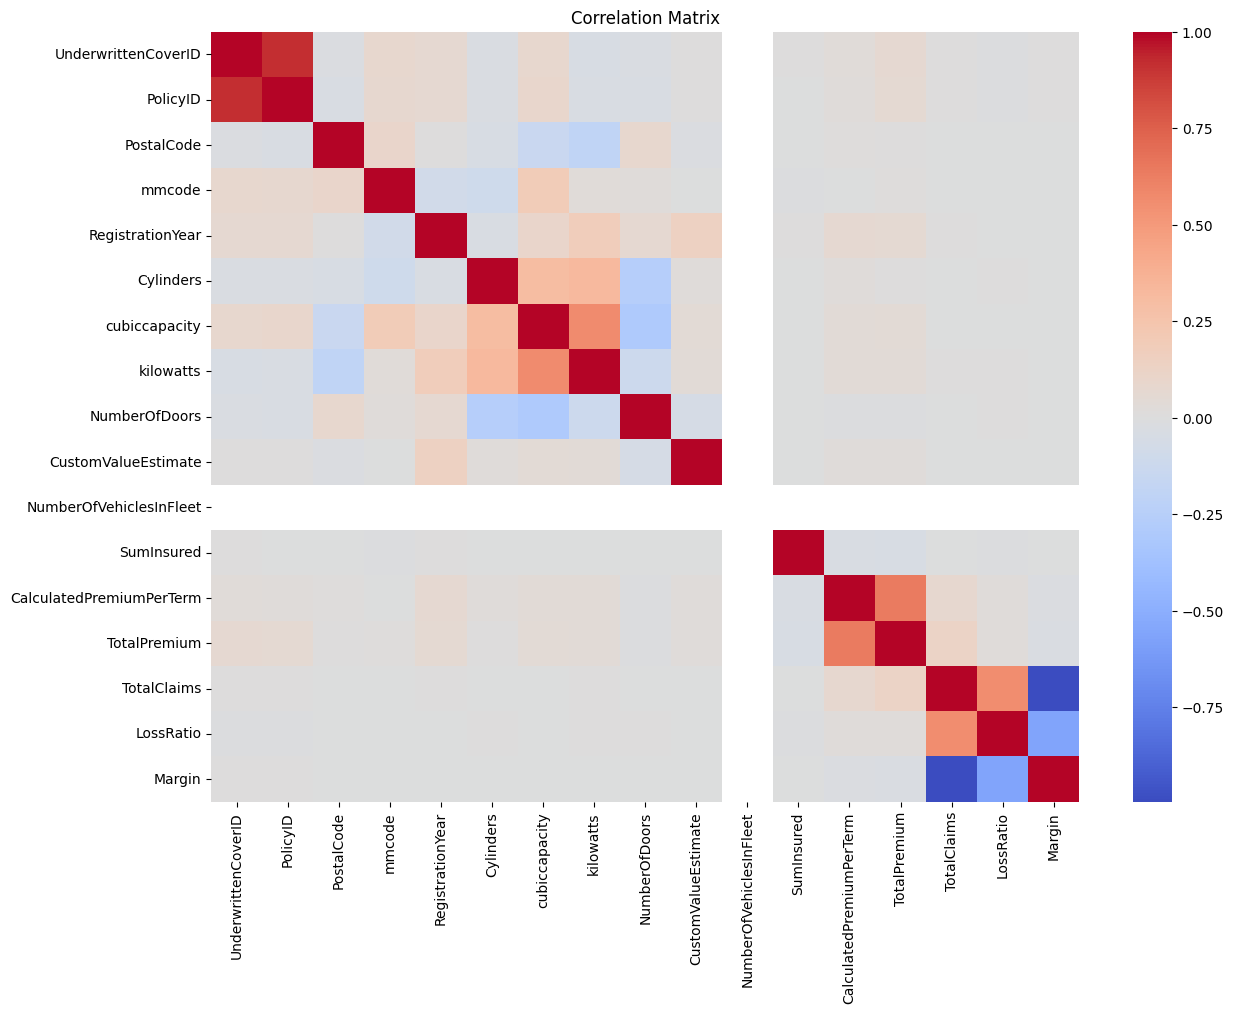

In [15]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

c:\Users\betya\Desktop\insranceriskanalysis\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
c:\Users\betya\Desktop\insranceriskanalysis\venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


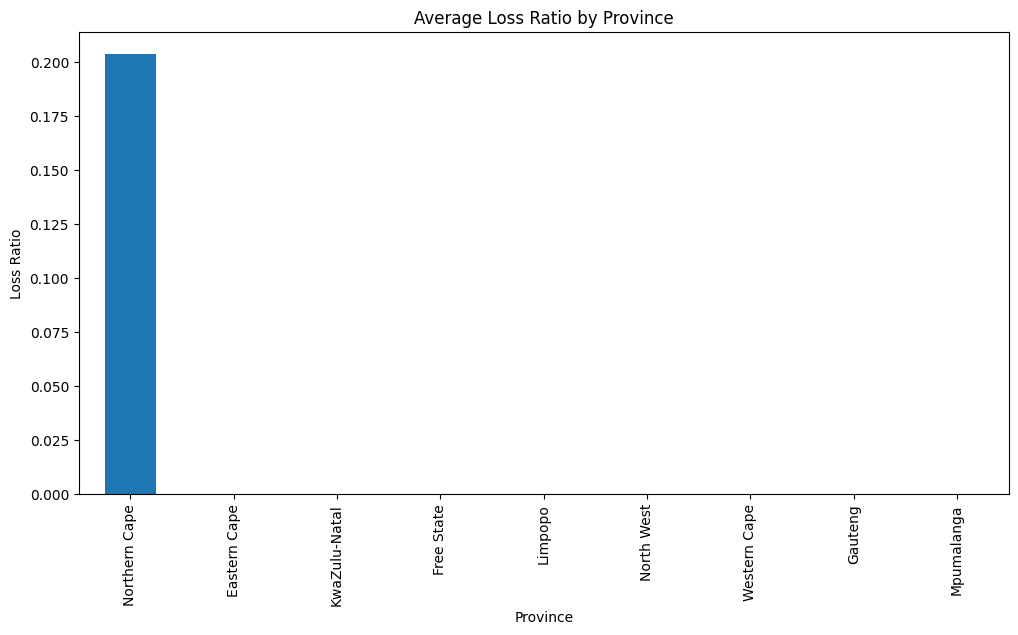

In [16]:
province_risk.sort_values().plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Average Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.show()

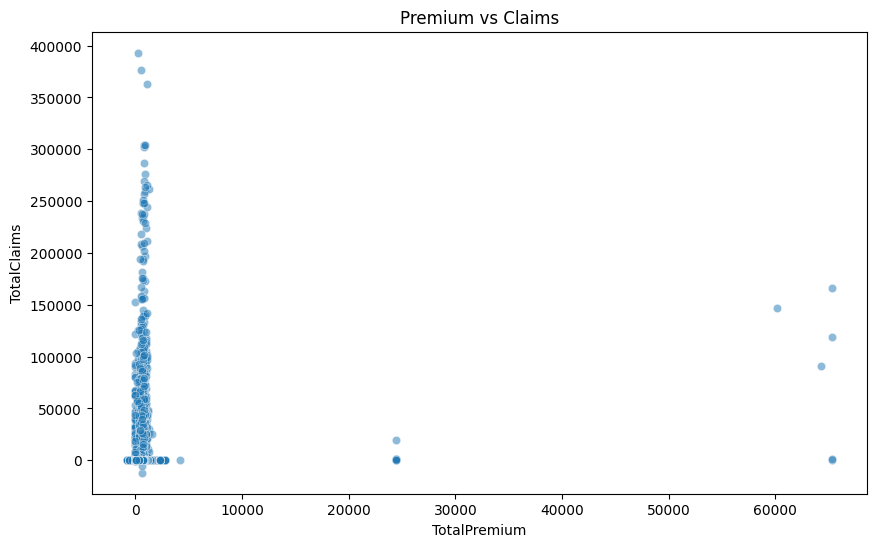

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    alpha=0.5
)

plt.title("Premium vs Claims")
plt.show()